**PCA-** Principal Component Analysis

- Reduce the number of a dimensions/variable of a dataset, while preserving as much as information as possible.

**HOW PCA WORKS??**

1- Standardize the data - (This puts all the features on the same scale)

2- Compute the covariance matrix (to identify correlation)

3- Calculate eigenvalues and eigenvectors of the covariance matrix

4- sort the eigen values in descending order to pick the highest one

5- transform the data

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
from sklearn import datasets

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
data = load_digits() #The Digits dataset contains images of handwritten digits (0–9).

In [ ]:
data

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

- each image is a tiny 8 x 8 square -> 64 features
- 8x8 = 64 pixels value
- it means each image is represented as 64 features(64 pixels value)

In [ ]:
data.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
data.target #a column in our data

array([0, 1, 2, ..., 8, 9, 8])

In [ ]:
df = pd.DataFrame(data.data,columns=data.feature_names)
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [ ]:
data.target #a column in our data

array([0, 1, 2, ..., 8, 9, 8])

In [ ]:
df['Target'] = data.target

In [ ]:
df

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,Target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0,9
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0,0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0,8
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0,9


In [ ]:
print("Target:",data.target[2])   #We are checking for a random target
data.data[2]

Target: 2


array([ 0.,  0.,  0.,  4., 15., 12.,  0.,  0.,  0.,  0.,  3., 16., 15.,
       14.,  0.,  0.,  0.,  0.,  8., 13.,  8., 16.,  0.,  0.,  0.,  0.,
        1.,  6., 15., 11.,  0.,  0.,  0.,  1.,  8., 13., 15.,  1.,  0.,
        0.,  0.,  9., 16., 16.,  5.,  0.,  0.,  0.,  0.,  3., 13., 16.,
       16., 11.,  5.,  0.,  0.,  0.,  0.,  3., 11., 16.,  9.,  0.])

In [ ]:
#We can say bigger the number, higher the brightness in the image. (0 --> full dark)

In [ ]:
# Reshaping for better view
data.data[2].reshape(8,8)

array([[ 0.,  0.,  0.,  4., 15., 12.,  0.,  0.],
       [ 0.,  0.,  3., 16., 15., 14.,  0.,  0.],
       [ 0.,  0.,  8., 13.,  8., 16.,  0.,  0.],
       [ 0.,  0.,  1.,  6., 15., 11.,  0.,  0.],
       [ 0.,  1.,  8., 13., 15.,  1.,  0.,  0.],
       [ 0.,  9., 16., 16.,  5.,  0.,  0.,  0.],
       [ 0.,  3., 13., 16., 16., 11.,  5.,  0.],
       [ 0.,  0.,  0.,  3., 11., 16.,  9.,  0.]])

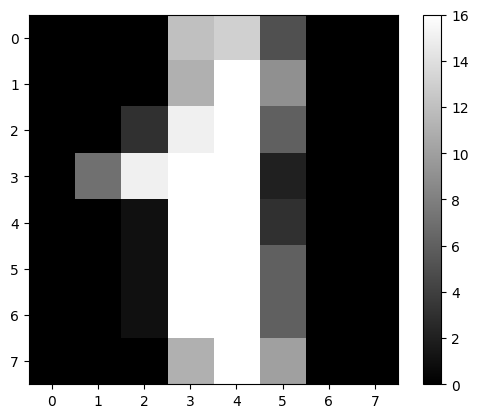

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(data.images[1], cmap=plt.cm.grey)
plt.colorbar()

In [ ]:
data.images[1]

array([[ 0.,  0.,  0., 12., 13.,  5.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16.,  9.,  0.,  0.],
       [ 0.,  0.,  3., 15., 16.,  6.,  0.,  0.],
       [ 0.,  7., 15., 16., 16.,  2.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  3.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  1., 16., 16.,  6.,  0.,  0.],
       [ 0.,  0.,  0., 11., 16., 10.,  0.,  0.]])

Our idea is to remove the columns which is not giving any information.

If we want only the number in the image and to remove the columns which is black(not imp)

In [ ]:
x = pd.DataFrame(data.data) #storing independent features in x
x

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1792,0.0,0.0,4.0,10.0,13.0,6.0,0.0,0.0,0.0,1.0,...,4.0,0.0,0.0,0.0,2.0,14.0,15.0,9.0,0.0,0.0
1793,0.0,0.0,6.0,16.0,13.0,11.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,6.0,16.0,14.0,6.0,0.0,0.0
1794,0.0,0.0,1.0,11.0,15.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,9.0,13.0,6.0,0.0,0.0
1795,0.0,0.0,2.0,10.0,7.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,5.0,12.0,16.0,12.0,0.0,0.0


In [ ]:
y = pd.DataFrame(data.target)   #storing target feature in variable y
y
#0th row representing a picture 0
#1st row representing a picture 1
#1796th row representing a picture 8

,0
0,0
1,1
2,2
3,3
4,4
...,...
1792,9
1793,0
1794,8
1795,9


#Let's implement PCA


**Step1:Standardization**

In [ ]:
#Some are high values, some are low values which might effect our PCA.
#So to put all the values in a proper range, we use Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
x_std = StandardScaler().fit_transform(x)   #Standardizing the values in x
x_std

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]])

**Step2: Covariance Matrix**

Before calculating the covariance we have to **Transpose** our data.

(Beacuse in numpy np.cov() it expects each row to be a feature and each column to be a row)

In [ ]:
x1 = x_std.T
x1

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.33501649, -0.33501649, -0.33501649, ..., -0.33501649,
        -0.33501649, -0.33501649],
       [-0.04308102, -1.09493684, -1.09493684, ..., -0.88456568,
        -0.67419451,  1.00877481],
       ...,
       [-1.14664746,  0.54856067,  1.56568555, ..., -0.12952258,
         0.8876023 ,  0.8876023 ],
       [-0.5056698 , -0.5056698 ,  1.6951369 , ..., -0.5056698 ,
        -0.5056698 , -0.26113572],
       [-0.19600752, -0.19600752, -0.19600752, ..., -0.19600752,
        -0.19600752, -0.19600752]])

In [ ]:
cov_matrix = np.cov(x1)

In [ ]:
cov_matrix #Tells us how much maximum information we will get by each and every column

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  1.00055679,  0.55692803, ..., -0.02988686,
         0.02656195, -0.04391324],
       [ 0.        ,  0.55692803,  1.00055679, ..., -0.04120565,
         0.07263924,  0.08256908],
       ...,
       [ 0.        , -0.02988686, -0.04120565, ...,  1.00055679,
         0.64868875,  0.26213704],
       [ 0.        ,  0.02656195,  0.07263924, ...,  0.64868875,
         1.00055679,  0.62077355],
       [ 0.        , -0.04391324,  0.08256908, ...,  0.26213704,
         0.62077355,  1.00055679]])

In [ ]:
#cov_matrix.min()

np.float64(-0.57051363323811)

**Step3: Eigen values and Eigen vectors**

Eigen vectors - direction of maximum information

Eigen values - How much information(variance) is captured by your Eigen vector

In [ ]:
Eigen_val, Eigen_vec = np.linalg.eig(cov_matrix)

In [ ]:
Eigen_val

array([7.34477606, 5.83549054, 5.15396118, 3.96623597, 2.9663452 ,
       2.57204442, 2.40600941, 2.06867355, 1.82993314, 1.78951739,
       1.69784616, 1.57287889, 1.38870781, 1.35933609, 1.32152536,
       1.16829176, 1.08368678, 0.99977862, 0.97438293, 0.90891242,
       0.82271926, 0.77631014, 0.71155675, 0.64552365, 0.59527399,
       0.5765018 , 0.52673155, 0.5106363 , 0.48686381, 0.45560107,
       0.44285155, 0.42230086, 0.3991063 , 0.39110111, 0.36094517,
       0.34860306, 0.3195963 , 0.05037444, 0.29406627, 0.27692285,
       0.06328961, 0.258273  , 0.24783029, 0.2423566 , 0.07635394,
       0.08246812, 0.09018543, 0.09840876, 0.10250434, 0.11188655,
       0.11932898, 0.12426371, 0.13321081, 0.14311427, 0.217582  ,
       0.15818474, 0.16875236, 0.20799593, 0.17612894, 0.2000909 ,
       0.18983516, 0.        , 0.        , 0.        ])

In [ ]:
Eigen_vec

array([[ 0.        ,  0.        ,  0.        , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.18223392, -0.04702701,  0.02358821, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.285868  , -0.0595648 , -0.05679875, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.103198  ,  0.24261778, -0.02227952, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.1198106 ,  0.16508926,  0.10036559, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.07149362,  0.07132924,  0.09244589, ...,  0.        ,
         0.        ,  0.        ]])

In [ ]:
#List of percentage variance explained by each principal component

total = sum(Eigen_val)

In [ ]:
var_explained = []
for i in Eigen_val:
  percentage = (i/total)*100
  var_explained.append(percentage)

In [ ]:
var_explained
#We can see PC1 is giving 12%, PC2 is giving 9%,... of information

[np.float64(12.033916097734904),
 np.float64(9.561054403097883),
 np.float64(8.444414892624566),
 np.float64(6.498407907524167),
 np.float64(4.860154875966403),
 np.float64(4.214119869271944),
 np.float64(3.9420828035674003),
 np.float64(3.3893809246383264),
 np.float64(2.998221011625232),
 np.float64(2.9320025512522068),
 np.float64(2.781805463550326),
 np.float64(2.5770550925819995),
 np.float64(2.2753033157642486),
 np.float64(2.227179739514353),
 np.float64(2.1652294318492435),
 np.float64(1.9141666064421259),
 np.float64(1.7755470851681938),
 np.float64(1.6380692742844212),
 np.float64(1.5964601688623428),
 np.float64(1.4891911870878194),
 np.float64(1.3479695658179378),
 np.float64(1.2719313702347599),
 np.float64(1.1658373505919493),
 np.float64(1.0576465985363224),
 np.float64(0.9753159471981139),
 np.float64(0.9445589897319981),
 np.float64(0.8630138269707229),
 np.float64(0.8366428536685183),
 np.float64(0.7976932484112456),
 np.float64(0.7464713709260611),
 np.float64(0.7255

In [ ]:
#We have to take principal components as much as our original data is giving information or atleast 80% of information

#PC1 + PC2 = 12+9 = 21% of information
#PC1 + PC2 + PC3 + PC4 = 12+9+8+6 = 35% of information

#Instead of doing it manually, we can do it using cumulative sum

In [ ]:
cum_sum_var = np.cumsum(var_explained)
cum_sum_var

array([ 12.0339161 ,  21.5949705 ,  30.03938539,  36.5377933 ,
        41.39794818,  45.61206805,  49.55415085,  52.94353177,
        55.94175279,  58.87375534,  61.6555608 ,  64.23261589,
        66.50791921,  68.73509895,  70.90032838,  72.81449499,
        74.59004207,  76.22811135,  77.82457152,  79.3137627 ,
        80.66173227,  81.93366364,  83.09950099,  84.15714759,
        85.13246353,  86.07702252,  86.94003635,  87.77667921,
        88.57437245,  89.32084382,  90.04642598,  90.73833722,
        91.39224576,  92.03303833,  92.62442244,  93.19558485,
        93.71922165,  93.80175675,  94.28356433,  94.73728359,
        94.84097932,  95.26414208,  95.67019515,  96.06727995,
        96.1923807 ,  96.32749911,  96.4752618 ,  96.63649786,
        96.80444425,  96.98776275,  97.18327518,  97.38687281,
        97.60512967,  97.83961267,  98.19610598,  98.45528092,
        98.73177018,  99.07255736,  99.36113266,  99.68896799,
       100.        , 100.        , 100.        , 100.  

In [ ]:
#Maximum explained variance ratio
max_ratio = pca.explained_variance_ratio_.max()
print(max_ratio)

0.12033916097734901


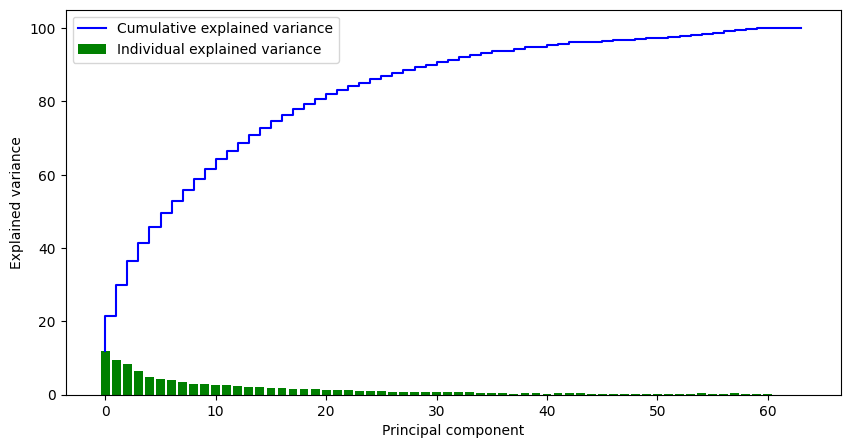

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(range(len(var_explained)), var_explained, label='Individual explained variance', color='g')
plt.step(range(len(cum_sum_var)),cum_sum_var, label='Cumulative explained variance',color='b')
plt.ylabel('Explained variance')
plt.xlabel('Principal component')
plt.legend()
plt.show()

after 30 there is going straigtly meaning no that imp captured -explain graph

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=25)

In [ ]:
pca_x = pca.fit_transform(x_std)

In [ ]:
pca_x.shape  #reduced 64 col to 25 PC

(1797, 25)

# PCA part is done

Selecting/Extracting the important features is PCA's work

Next thing is to build our models like lr, dt, rf

                                 -----

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(pca_x, y, test_size=0.2,random_state=23)

In [ ]:
x_train.shape, x_test.shape

((1437, 25), (360, 25))

In [ ]:
y_train.shape, y_test.shape

((1437, 1), (360, 1))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

In [ ]:
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
predict = dt.predict(x_test)
predict

array([4, 6, 5, 8, 5, 4, 0, 5, 4, 5, 6, 4, 8, 7, 8, 5, 1, 8, 5, 6, 3, 4,
       2, 2, 4, 9, 8, 1, 8, 2, 8, 7, 8, 9, 5, 5, 3, 3, 4, 5, 7, 9, 0, 4,
       1, 2, 7, 6, 5, 5, 2, 7, 3, 3, 8, 6, 1, 2, 1, 9, 5, 5, 3, 1, 6, 7,
       6, 8, 1, 5, 4, 2, 5, 8, 9, 7, 5, 4, 6, 0, 1, 0, 5, 4, 6, 8, 2, 2,
       5, 4, 2, 5, 1, 5, 1, 1, 3, 8, 5, 9, 2, 9, 8, 8, 4, 4, 6, 1, 8, 1,
       8, 0, 3, 2, 4, 6, 5, 9, 6, 2, 9, 1, 3, 4, 1, 4, 0, 9, 7, 4, 2, 0,
       1, 1, 4, 8, 6, 6, 5, 0, 7, 6, 3, 5, 9, 4, 3, 4, 9, 7, 3, 7, 8, 3,
       2, 1, 5, 7, 7, 6, 2, 0, 0, 4, 1, 2, 1, 7, 5, 1, 2, 8, 7, 6, 2, 9,
       5, 9, 3, 2, 8, 9, 0, 7, 9, 2, 2, 8, 9, 2, 6, 7, 0, 1, 4, 7, 1, 9,
       0, 6, 1, 5, 4, 5, 2, 2, 6, 0, 9, 2, 9, 1, 8, 6, 1, 6, 0, 3, 8, 5,
       8, 3, 3, 1, 7, 4, 0, 6, 8, 1, 7, 1, 5, 9, 0, 6, 9, 7, 6, 2, 6, 0,
       9, 9, 5, 1, 1, 3, 9, 9, 9, 5, 7, 3, 5, 2, 3, 3, 9, 4, 2, 5, 9, 5,
       8, 9, 3, 7, 2, 5, 6, 0, 8, 8, 8, 6, 5, 0, 2, 3, 7, 0, 2, 0, 0, 4,
       7, 9, 1, 5, 2, 9, 2, 8, 2, 9, 0, 4, 2, 0, 9,

In [ ]:
Compare = pd.DataFrame({'Actual data':y_test[0], 'Predicted':predict})

In [ ]:
Compare

,Actual data,Predicted
1754,4,4
880,6,6
25,5,5
1067,8,8
176,5,5
...,...,...
1299,2,3
1045,6,6
274,8,5
1473,6,6


In [ ]:
from sklearn.metrics import *

In [ ]:
accuracy_score(y_test, predict)
#out of 65 features, with just 25 features we are getting 83%

0.8305555555555556

Apply Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression().fit(x_train, y_train)
y_pred = lr.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
accuracy_score(y_test, y_pred)

0.95